# Hydroelectric Flow Rate Prediction
Predicting river discharge (ft³/s) from gage height and lagged flow using linear regression.

**Station:** USGS-12510500 (Yakima River, WA)  
**Why flow rate?** Power output is directly proportional to flow rate (P = ρgHQη), so predicting flow is equivalent to predicting power — without needing to assume unknown plant parameters like head height.

## 1. Imports

In [30]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

## 2. Fetch Data from USGS

In [31]:
STATION = "12510500"
END = datetime.today()
START = END - timedelta(days=1095)  # Increased to 2 years (730 days)

url = (f"https://waterservices.usgs.gov/nwis/iv/"
       f"?sites={STATION}&parameterCd=00060,00065"
       f"&startDT={START.strftime('%Y-%m-%d')}&endDT={END.strftime('%Y-%m-%d')}"
       f"&format=rdb")

r = requests.get(url, timeout=30)
lines = [l for l in r.text.splitlines() if not l.startswith('#')]
raw = pd.read_csv(StringIO('\n'.join(lines)), sep='\t', skiprows=[1], low_memory=False)

## 3. Clean & Prepare

In [32]:
FEATURES = []
TARGETS = []

# 1. Create 30 days of history (past month)
for i in range(1, 31):
    col_name = f'flow_lag_{i}d'
    df[col_name] = df['flow_cfs'].shift(i)
    FEATURES.append(col_name)

# 2. Create 7 days of targets (next week)
for i in range(1, 8):
    col_name = f'target_day_{i}'
    df[col_name] = df['flow_cfs'].shift(-i)
    TARGETS.append(col_name)

# Drop rows that are missing historical data or future targets
df = df.dropna()

X = df[FEATURES].values
y = df[TARGETS].values  # y is now a 2D array of shape (N, 7)

print(f"Feature matrix X shape: {X.shape}") 
print(f"Target matrix y shape: {y.shape}")

Feature matrix X shape: (92, 30)
Target matrix y shape: (92, 7)


## 4. Feature Engineering
We predict next-hour flow rate using current and past gage height and flow as inputs.

In [33]:
FEATURES = []
TARGETS = []

# 1. Create 30 days of history (past month)
for i in range(1, 31):
    col_name = f'flow_lag_{i}d'
    df[col_name] = df['flow_cfs'].shift(i)
    FEATURES.append(col_name)

# 2. Create 7 days of targets (next week)
for i in range(1, 8):
    col_name = f'target_day_{i}'
    df[col_name] = df['flow_cfs'].shift(-i)
    TARGETS.append(col_name)

# Drop rows that are missing historical data or future targets
df = df.dropna()

X = df[FEATURES].values
y = df[TARGETS].values  # y is now a 2D array of shape (N, 7)

print(f"Feature matrix X shape: {X.shape}") 
print(f"Target matrix y shape: {y.shape}")

Feature matrix X shape: (55, 30)
Target matrix y shape: (55, 7)


## 5. Train / Test Split

In [34]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = df.index[split:]

# LinearRegression natively supports multi-target y arrays
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Calculate the average performance across all 7 predicted days
r2 = r2_score(y_test, y_pred, multioutput='uniform_average')
mae = mean_absolute_error(y_test, y_pred, multioutput='uniform_average')

print(f"Average 7-Day R²  = {r2:.4f}")
print(f"Average 7-Day MAE = {mae:.1f} ft³/s")

# If you want to see how accurate it is on Day 1 vs Day 7 specifically:
mae_per_day = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
for i, m in enumerate(mae_per_day, 1):
    print(f"  Day {i} MAE: {m:.1f} ft³/s")

Average 7-Day R²  = -18355.1569
Average 7-Day MAE = 40726.5 ft³/s
  Day 1 MAE: 12534.1 ft³/s
  Day 2 MAE: 23495.2 ft³/s
  Day 3 MAE: 33617.2 ft³/s
  Day 4 MAE: 42056.7 ft³/s
  Day 5 MAE: 50397.2 ft³/s
  Day 6 MAE: 57900.9 ft³/s
  Day 7 MAE: 65084.1 ft³/s


## 6. Visualize Results

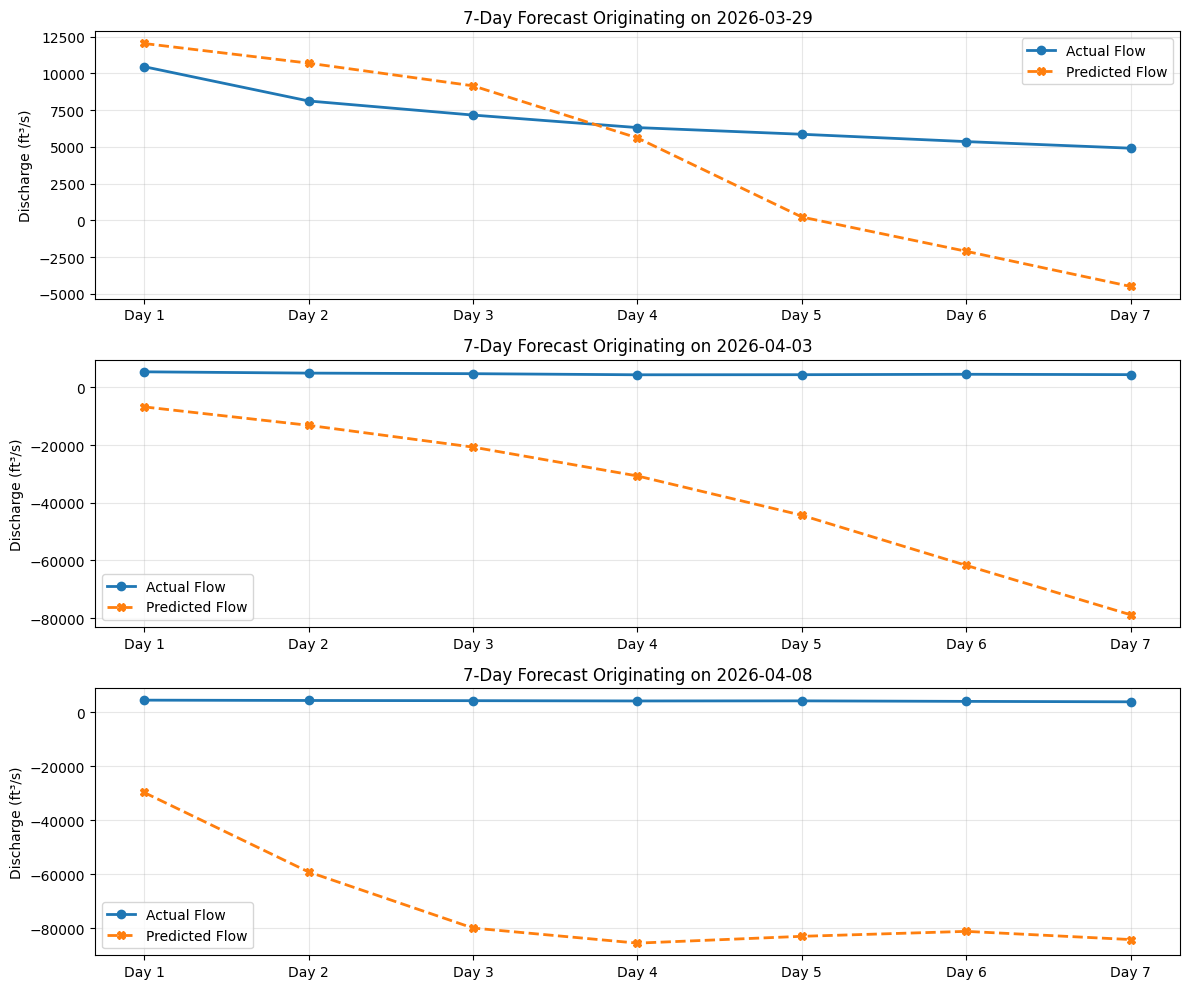

In [35]:
# Pick 3 distinct starting points in the test set to visualize
# (Start, Middle, and End of the test period)
sample_indices = [0, len(y_test) // 2, len(y_test) - 1]

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(12, 10))
days_x = [f"Day {d}" for d in range(1, 8)]

for i, idx in enumerate(sample_indices):
    start_date = dates_test[idx].date()
    
    # Extract the full 7-day arrays for this specific row
    actual_7_days = y_test[idx]
    pred_7_days = y_pred[idx]
    
    # Plot Actual vs Predicted for this 7-day window
    axes[i].plot(days_x, actual_7_days, label='Actual Flow', marker='o', linewidth=2)
    axes[i].plot(days_x, pred_7_days, label='Predicted Flow', marker='X', linestyle='--', linewidth=2)
    
    axes[i].set_title(f'7-Day Forecast Originating on {start_date}', fontsize=12)
    axes[i].set_ylabel('Discharge (ft³/s)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature Coefficients

In [ ]:
# Grab the 30 coefficients specifically for the Day 1 target
coef_day1 = model.coef_[0]

coef_df = pd.DataFrame({'feature': FEATURES, 'coefficient': coef_day1})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=True)

# Increased figure height to 8 so 30 features are actually readable
plt.figure(figsize=(8, 8)) 
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients (Impact on Day 1 Prediction)')
plt.tight_layout()
plt.show()